<a href="https://colab.research.google.com/github/JenilMP-09/Syntecxhub_Statistical_Plots_And_Distribution_Analysis/blob/main/Syntecxhub_Statistical_Plots_And_Distribution_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Statistical plots & distribution analysis

    * Draw histograms, KDEs and boxplots to inspect distributions
    * Compare distributions across groups (e.g., region A vs B)
    * Detect outliers and comment on skewness / spread.
    * Export plots and a one-paragraph interpretation.

In [602]:
# Importing libraries:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style()

In [603]:
# Load dataset:

cafe_df = pd.read_csv("/content/drive/MyDrive/Data_Science_Folder/Datasets/dirty_cafe_sales.csv")

In [604]:
# Display first 5 rows of a dataset:

cafe_df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [605]:
# Showing technical summary of a dataset:

cafe_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   object
 3   Price Per Unit    9821 non-null   object
 4   Total Spent       9827 non-null   object
 5   Payment Method    7421 non-null   object
 6   Location          6735 non-null   object
 7   Transaction Date  9841 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB


* Here, majority of the columns contains missing values (null values).

<h3>To handle missing values:</h3>

In [606]:
cafe_df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [607]:
# Replacing "UNKNOWN" & "ERROR" values with "NaN" in a dataset:

cafe_df.replace(["UNKNOWN", "ERROR"], np.nan, inplace=True)

In [608]:
cafe_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9031 non-null   object
 2   Quantity          9521 non-null   object
 3   Price Per Unit    9467 non-null   object
 4   Total Spent       9498 non-null   object
 5   Payment Method    6822 non-null   object
 6   Location          6039 non-null   object
 7   Transaction Date  9540 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB


In [609]:
# Calculate the missing value rate of a dataset:

print(cafe_df.isnull().sum() * 100 / len(cafe_df))

Transaction ID       0.00
Item                 9.69
Quantity             4.79
Price Per Unit       5.33
Total Spent          5.02
Payment Method      31.78
Location            39.61
Transaction Date     4.60
dtype: float64


* So, missing value rate of each column is between 0% - 39.60%.
* Therefore, we don't need to drop any column.
* Just need to fill the missing values using mean, median, or mode.

In [610]:
# Drop "Transaction ID" column:

cafe_df.drop("Transaction ID", axis=1, inplace=True)

##### For "**Item**" column:

In [611]:
# Fill "NaN" values with most common value using .mode() in "Item" column:

cafe_df["Item"].fillna(cafe_df["Item"].mode()[0], inplace=True)

/tmp/ipykernel_586/3212200283.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  cafe_df["Item"].fillna(cafe_df["Item"].mode()[0], inplace=True)


In [612]:
cafe_df.Item.isna().sum()

np.int64(0)

##### For "**Quantity**" column:

In [613]:
# Checking type of "Quantity" column:

cafe_df["Quantity"].dtype

dtype('O')

* Values in "Quantity" column are numeric but type of column is "object".

In [614]:
# Convert the values from "object" to "numeric" type:

cafe_df["Quantity"] = pd.to_numeric(cafe_df["Quantity"])

In [615]:
# Fill "NaN" values using .median() in "Quantity" column:

cafe_df.fillna({"Quantity": cafe_df["Quantity"].median()}, inplace=True)

In [616]:
cafe_df.Quantity.isna().sum()

np.int64(0)

##### For "**Price Per Unit**" column:

In [617]:
# Checking type of "Price Per Unit" column:

cafe_df["Price Per Unit"].dtype

dtype('O')

* Values in "Price Per Unit" column are numeric but type of column is "object".

In [618]:
# Convert the values from "object" to "numeric" type:

cafe_df["Price Per Unit"] = pd.to_numeric(cafe_df["Price Per Unit"])

In [619]:
# Fill "NaN" values using .median() in "Price Per Unit" column:

cafe_df["Price Per Unit"].fillna(cafe_df["Price Per Unit"].median(), inplace=True)

/tmp/ipykernel_586/4198750141.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  cafe_df["Price Per Unit"].fillna(cafe_df["Price Per Unit"].median(), inplace=True)


In [620]:
# Mapping price value with it's respective item:

price_map = {
  'Coffee': 2,
  'Cake': 3,
  'Cookie': 1,
  'Salad': 5,
  'Smoothie': 4,
  'Juice': 3,
  'Sandwich': 4,
  'Tea': 1.5
}

# Create the "Price Per Unit" column from scratch based on "Item" column:

cafe_df['Price Per Unit'] = cafe_df['Item'].map(price_map)

In [621]:
cafe_df.head()

,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16
2,Cookie,4.0,1.0,NaN,Credit Card,In-store,2023-07-19
3,Salad,2.0,5.0,10.0,NaN,NaN,2023-04-27
4,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [622]:
cafe_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Item              10000 non-null  object 
 1   Quantity          10000 non-null  float64
 2   Price Per Unit    10000 non-null  float64
 3   Total Spent       9498 non-null   object 
 4   Payment Method    6822 non-null   object 
 5   Location          6039 non-null   object 
 6   Transaction Date  9540 non-null   object 
dtypes: float64(2), object(5)
memory usage: 547.0+ KB


##### For "**Total Spent**" column:

In [623]:
# Create a "Total Spent" column from scratch using "Quantity" & "Price Per Unit" column:

cafe_df["Total Spent"] = cafe_df["Quantity"] * cafe_df["Price Per Unit"]

In [624]:
cafe_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Item              10000 non-null  object 
 1   Quantity          10000 non-null  float64
 2   Price Per Unit    10000 non-null  float64
 3   Total Spent       10000 non-null  float64
 4   Payment Method    6822 non-null   object 
 5   Location          6039 non-null   object 
 6   Transaction Date  9540 non-null   object 
dtypes: float64(3), object(4)
memory usage: 547.0+ KB


##### For "**Payment Method**" column:

In [625]:
# Fill "NaN" values with explicit "Unknown" category in "Payment Method" column:

cafe_df["Payment Method"].fillna("Unknown", inplace=True)

/tmp/ipykernel_586/1043601232.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  cafe_df["Payment Method"].fillna("Unknown", inplace=True)


In [626]:
cafe_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Item              10000 non-null  object 
 1   Quantity          10000 non-null  float64
 2   Price Per Unit    10000 non-null  float64
 3   Total Spent       10000 non-null  float64
 4   Payment Method    10000 non-null  object 
 5   Location          6039 non-null   object 
 6   Transaction Date  9540 non-null   object 
dtypes: float64(3), object(4)
memory usage: 547.0+ KB


##### For "**Location**" column:

In [627]:
# Fill "NaN" values with explicit "Unknown" category in "Location" column:

cafe_df["Location"].fillna("Unknown", inplace=True)

/tmp/ipykernel_586/860718631.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  cafe_df["Location"].fillna("Unknown", inplace=True)


In [628]:
cafe_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Item              10000 non-null  object 
 1   Quantity          10000 non-null  float64
 2   Price Per Unit    10000 non-null  float64
 3   Total Spent       10000 non-null  float64
 4   Payment Method    10000 non-null  object 
 5   Location          10000 non-null  object 
 6   Transaction Date  9540 non-null   object 
dtypes: float64(3), object(4)
memory usage: 547.0+ KB


##### For "**Transaction Date**" column:

In [629]:
# Convert "Transaction Date" column from object/string to datetime type:

cafe_df["Transaction Date"] = pd.to_datetime(cafe_df["Transaction Date"], errors="coerce")

In [630]:
cafe_df.head()

,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16
2,Cookie,4.0,1.0,4.0,Credit Card,In-store,2023-07-19
3,Salad,2.0,5.0,10.0,Unknown,Unknown,2023-04-27
4,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [631]:
cafe_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Item              10000 non-null  object        
 1   Quantity          10000 non-null  float64       
 2   Price Per Unit    10000 non-null  float64       
 3   Total Spent       10000 non-null  float64       
 4   Payment Method    10000 non-null  object        
 5   Location          10000 non-null  object        
 6   Transaction Date  9540 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(3), object(3)
memory usage: 547.0+ KB


#### Plots & Their Interpretations:

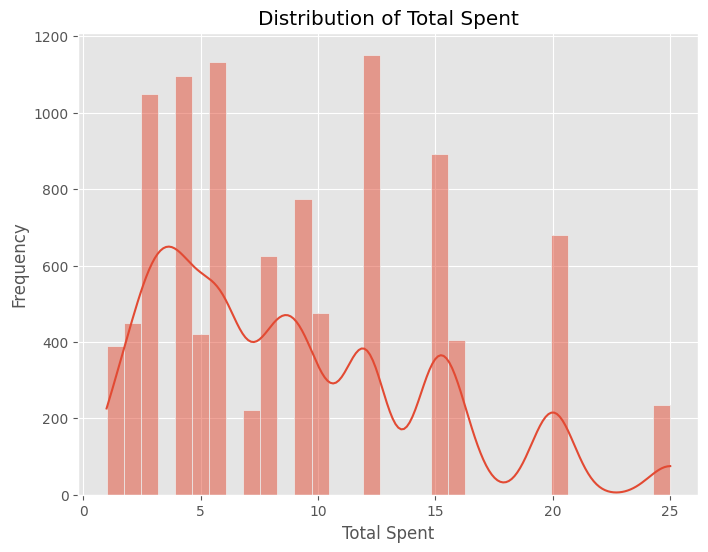

In [632]:
# Display a histogram of distribution of total spent amount:

plt.figure(figsize=(8, 6))
sns.histplot(cafe_df["Total Spent"], kde=True)
plt.title("Distribution of Total Spent")
plt.xlabel("Total Spent")
plt.ylabel("Frequency")
plt.show()

* Right-skewed with a long tail out to 25.
* Most transactions land between 1 and 12.
* Total Spent = Quantity * (Price Per Unit)

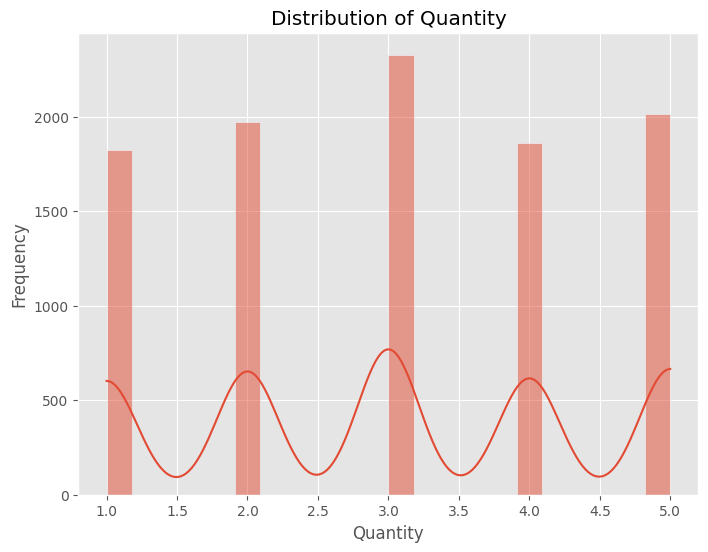

In [633]:
# display a histogram of distribution of quantity:

plt.figure(figsize=(8, 6))
sns.histplot(cafe_df["Quantity"], kde=True)
plt.title("Distribution of Quantity")
plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.show()

* Close to uniform across all five possible values.
* Each occurring roughly 1800-2300 times.

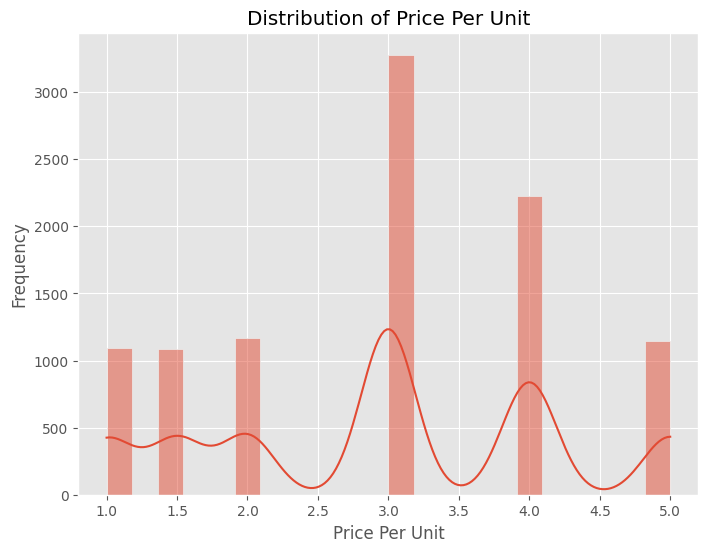

In [634]:
# Display a histogram of price per unit:

plt.figure(figsize=(8, 6))
sns.histplot(cafe_df["Price Per Unit"], kde=True)
plt.title("Distribution of Price Per Unit")
plt.xlabel("Price Per Unit")
plt.ylabel("Frequency")
plt.show()

* Roughly uniform across its six fixed price points, but 3.0 and 4.0 stand taller than the rest because two items share each price.

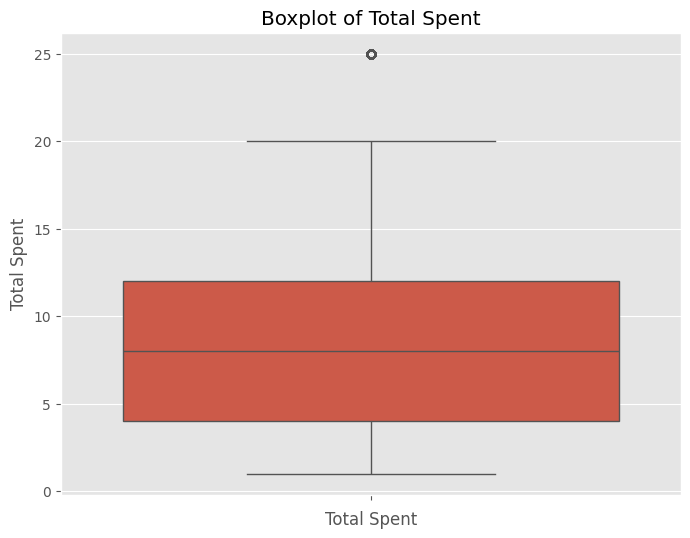

In [635]:
# Display a boxplot of total spent amount:

plt.figure(figsize=(8, 6))
sns.boxplot(cafe_df["Total Spent"])
plt.title("Boxplot of Total Spent")
plt.xlabel("Total Spent")
plt.show()

* Here, median is 8, the IQR box spans roughly 4 to 12, and whiskers reach down to 1 and up to 20.
* 236 outlier rows (~2.4%)

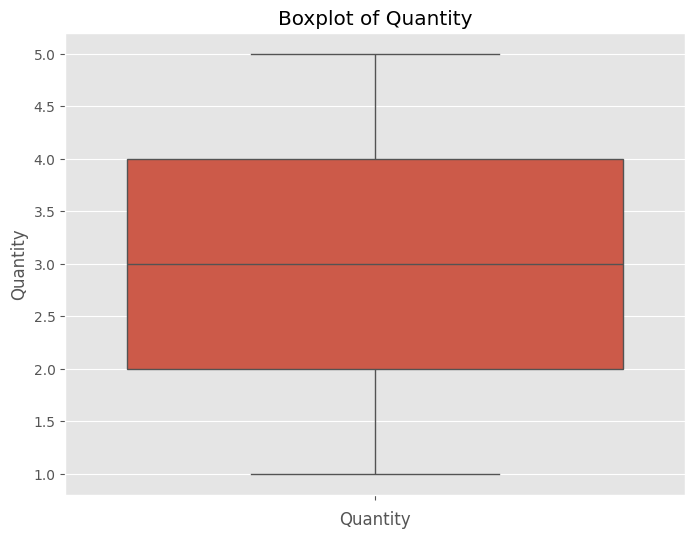

In [636]:
# Display a boxplot of quantity:

plt.figure(figsize=(8, 6))
sns.boxplot(cafe_df["Quantity"])
plt.title("Boxplot of Quantity")
plt.xlabel("Quantity")
plt.show()

* Here, median is 3, IQR 2-4, whiskers spanning the full 1-5 range, zero outliers.

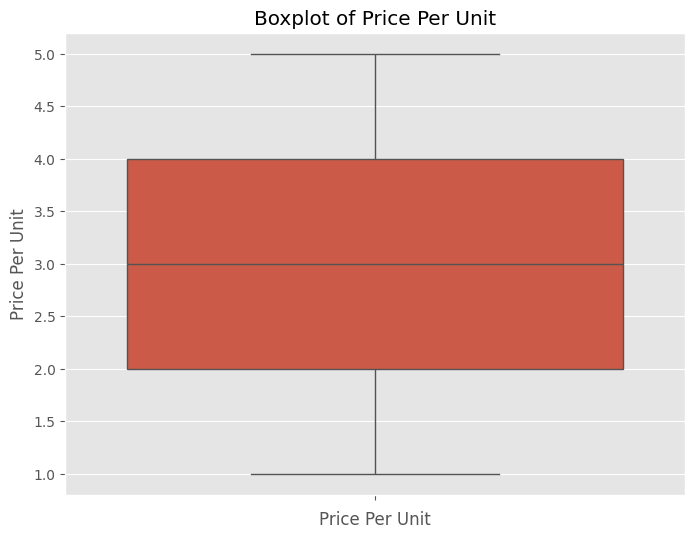

In [637]:
# Display a boxplot of price per unit:

plt.figure(figsize=(8, 6))
sns.boxplot(cafe_df["Price Per Unit"])
plt.title("Boxplot of Price Per Unit")
plt.xlabel("Price Per Unit")
plt.show()

* Here, nearly identical shape to the quantity boxplot.
* Median is 3, IQR 2-4, no outliers.